# Assembly stats

-----
| Name | Date | 
| - | - |
| Keiler Collier | 30 April 2026 |
-----

Here, we assess the effectiveness of each NOVOplasty assembly run.
We used a Zebra Finch (*Taeniopygia guttata*) as the seed sequence for these assemblies.
Because the Zebra Finch is a passerine, if we see that passerine assemblies are completed more often than they should be, we'll need to rerun those assemblies.

## 0. - Python imports

In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import chi2, kruskal
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import (
    confusion_matrix, accuracy_score, balanced_accuracy_score, f1_score, log_loss
)
import matplotlib.pyplot as plt

## 1. Dataset assembly

We computed `Assembly level` based on the highest level of assembly in each NOVOplasty output directory.

- `failed` = highest level is `contigs_tmp`
- `partial_success` = contains a `Contig_1` file (successfully extended a seed)
- `success` = contains a `Circularized_assembly` file (successfully assembled entire mitogenome)

Total individuals: 288 (`success`: 63, `partial_success`: 130, `failed`: 95)

The canonical merged data now lives in `mitogenome_assembly_results.csv`.
An explanation of all columns in the dataset can be found in the [mitogenome_assembly_results_key.md](mitogenome_assembly_results_key.md).

## 2. Summary statistics of `assembly_level`

In [3]:
# Load canonical merged results and validate required columns.
df = pd.read_csv('../mitogenome_assembly_results.csv')
required_cols = {'directory_name', 'species', 'assembly_level', 'annotation_success'}
missing_cols = required_cols.difference(df.columns)
if missing_cols:
    raise ValueError(f'Missing required columns: {sorted(missing_cols)}')

# Keep a fixed plotting order for assembly outcomes
level_order = ['failed', 'partial_success', 'success']


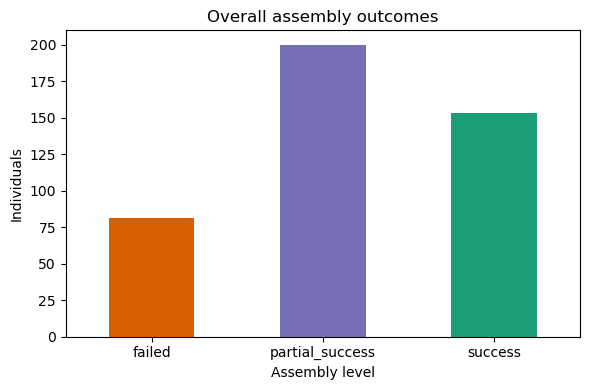

In [4]:
# 1) Overall assembly outcome counts
overall_counts = (df['assembly_level'].value_counts().reindex(level_order, fill_value=0))

ax = overall_counts.plot(kind='bar', color=['#d95f02', '#7570b3', '#1b9e77'], figsize=(6, 4))
ax.set_title('Overall assembly outcomes')
ax.set_xlabel('Assembly level')
ax.set_ylabel('Individuals')
plt.xticks(rotation=0)
plt.tight_layout()

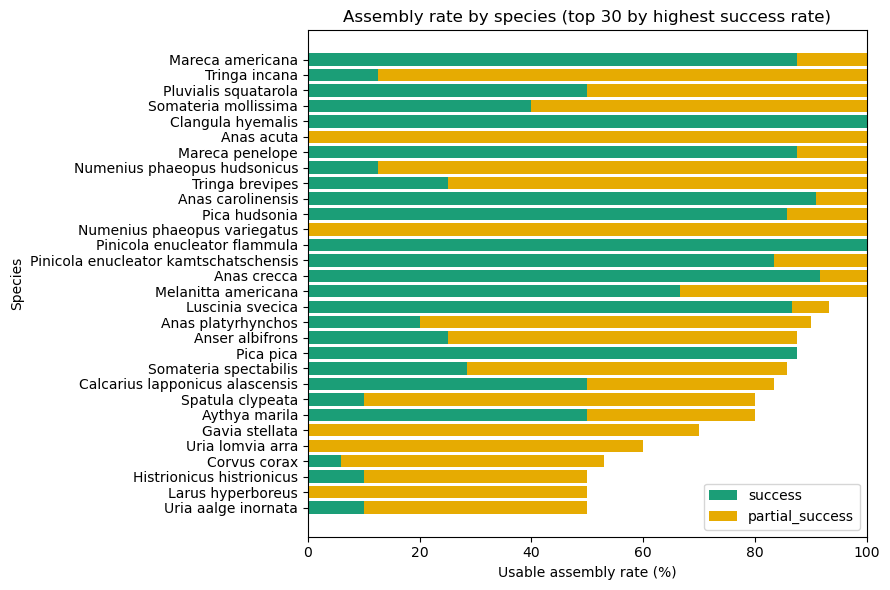

,species,n,success_pct,partial_pct,usable_pct
0,Corvus corax,17,5.882353,47.058824,52.941176
1,Luscinia svecica,15,86.666667,6.666667,93.333333
2,Clangula hyemalis,14,100.000000,0.000000,100.000000
3,Anas crecca,12,91.666667,8.333333,100.000000
4,Anas carolinensis,11,90.909091,9.090909,100.000000
5,Pluvialis squatarola,10,50.000000,50.000000,100.000000
6,Somateria mollissima,10,40.000000,60.000000,100.000000
7,Anas platyrhynchos,10,20.000000,70.000000,90.000000
8,Aythya marila,10,50.000000,30.000000,80.000000
9,Spatula clypeata,10,10.000000,70.000000,80.000000


In [5]:
# 2) Per-species assembly rate (top 30 species by number of individuals)
# "Usable" = circularized (success) + contigs/options only (partial_success)
species_summary = (
    df.assign(
        is_success=df['assembly_level'].eq('success'),
        is_partial=df['assembly_level'].eq('partial_success'),
    )
    .groupby('species', as_index=False)
    .agg(
        n=('directory_name', 'size'),
        n_success=('is_success', 'sum'),
        n_partial=('is_partial', 'sum'),
    )
)
species_summary['success_pct'] = species_summary['n_success'] / species_summary['n'] * 100
species_summary['partial_pct'] = species_summary['n_partial'] / species_summary['n'] * 100
species_summary['usable_pct'] = species_summary['success_pct'] + species_summary['partial_pct']

top_species = species_summary.sort_values(['n', 'usable_pct'], ascending=[False, False]).head(30)
plot_df = top_species.sort_values('usable_pct')

y = np.arange(len(plot_df))
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(y, plot_df['success_pct'], color='#1b9e77', label='success')
ax.barh(
    y,
    plot_df['partial_pct'],
    left=plot_df['success_pct'],
    color='#e6ab02',
    label='partial_success',
)
ax.set_yticks(y)
ax.set_yticklabels(plot_df['species'])
ax.set_title('Assembly rate by species (top 30 by highest success rate)')
ax.set_xlabel('Usable assembly rate (%)')
ax.set_ylabel('Species')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

top_species[['species', 'n', 'success_pct', 'partial_pct', 'usable_pct']].reset_index(drop=True)

In [6]:
asm_successes=np.array(df['assembly_level'].isin(['success', 'partial_success']))
print(f'{round(asm_successes.sum()/len(df)*100, 2)}% of assembly efforts were successful or partially successful.')
print(f'This was {asm_successes.sum()} of {len(df)} assemblies.')

81.34% of assembly efforts were successful or partially successful.
This was 353 of 434 assemblies.


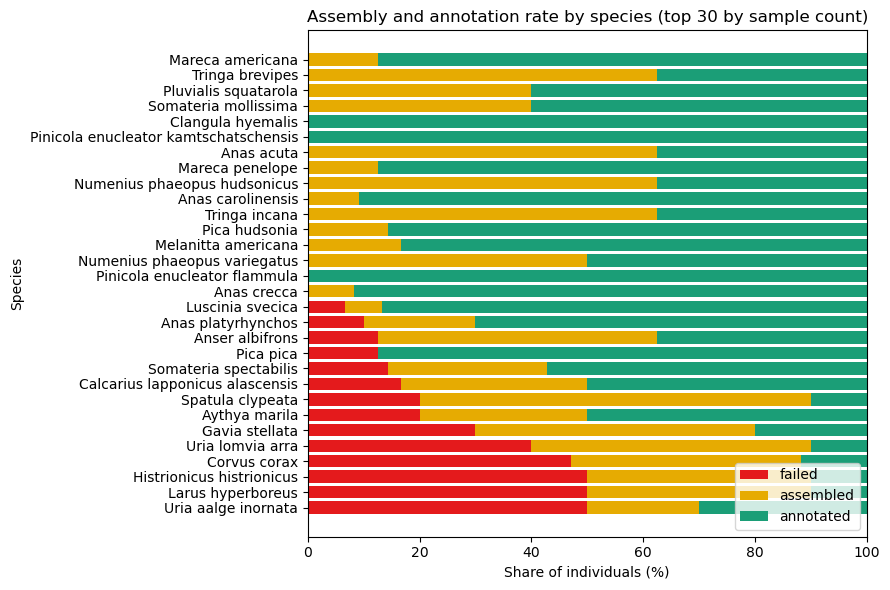

In [7]:
# 3) Per-species pipeline outcome (top 30 species by sample count)
# failed = assembly failed; assembled = success/partial but not annotated; annotated = MitoZ success
is_annotated = df['annotation_success'].eq('success')
is_assembled = df['assembly_level'].isin(['success', 'partial_success']) & ~is_annotated
is_failed = ~is_annotated & ~is_assembled

pipeline_summary = (
    df.assign(
        is_failed=is_failed,
        is_assembled=is_assembled,
        is_annotated=is_annotated,
    )
    .groupby('species', as_index=False)
    .agg(
        n=('directory_name', 'size'),
        n_failed=('is_failed', 'sum'),
        n_assembled=('is_assembled', 'sum'),
        n_annotated=('is_annotated', 'sum'),
    )
)
pipeline_summary['failed_pct'] = pipeline_summary['n_failed'] / pipeline_summary['n'] * 100
pipeline_summary['assembled_pct'] = pipeline_summary['n_assembled'] / pipeline_summary['n'] * 100
pipeline_summary['annotated_pct'] = pipeline_summary['n_annotated'] / pipeline_summary['n'] * 100

pipeline_summary['complete_pct'] = (
    pipeline_summary['assembled_pct'] + pipeline_summary['annotated_pct']
)

top_pipeline = pipeline_summary.sort_values(['n', 'complete_pct'], ascending=[False, False]).head(30)
plot_df = top_pipeline.sort_values('complete_pct')

y = np.arange(len(plot_df))
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(y, plot_df['failed_pct'], color='#e41a1c', label='failed')
ax.barh(
    y,
    plot_df['assembled_pct'],
    left=plot_df['failed_pct'],
    color='#e6ab02',
    label='assembled',
)
ax.barh(
    y,
    plot_df['annotated_pct'],
    left=plot_df['failed_pct'] + plot_df['assembled_pct'],
    color='#1b9e77',
    label='annotated',
)
ax.set_yticks(y)
ax.set_yticklabels(plot_df['species'])
ax.set_title('Assembly and annotation rate by species (top 30 by sample count)')
ax.set_xlabel('Share of individuals (%)')
ax.set_ylabel('Species')
ax.set_xlim(0, 100)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

#top_pipeline[
#    ['species', 'n', 'failed_pct', 'assembled_pct', 'annotated_pct', 'complete_pct']
#].reset_index(drop=True)

## 3. Summary statistics of annotation success

We only attempted to annotate assemblies which were at least partially successful.

In [28]:
ann_successes=np.array(df['annotation_success'].isin(['success']))
print(f'{ann_successes.sum()} of annotation efforts were successful.')
print(f'This was {round((ann_successes.sum()/len(df))*100,2)}% of all assemblies ({len(df)}), and {round((ann_successes.sum()/asm_successes.sum()*100),2)}% of successful assemblies ({asm_successes.sum()}).')

201 of annotation efforts were successful.
This was 46.31% of all assemblies (434), and 56.94% of successful assemblies (353).


In [29]:
inds_fully_ass=len(df[df['assembly_level'] == 'success'])
inds_fully_ass_ann=len((df[(df['annotation_success'] == 'success') & (df['assembly_level'] == 'success')]))
inds_partial_ass=len(df[df['assembly_level'] == 'partial_success'])
inds_partial_ass_ann=len(df[(df['annotation_success'] == 'success') & (df['assembly_level'] == 'partial_success')])

print(f'There are {inds_fully_ass} circularized assemblies, of which {inds_fully_ass_ann} are annotated.')
print(f'There are {inds_partial_ass} partial assemblies, of which {inds_partial_ass_ann} are annotated.')

There are 153 circularized assemblies, of which 150 are annotated.
There are 200 partial assemblies, of which 50 are annotated.


In [ ]:
successful_ann=df[['annotation_success','assembly_level']][df['annotation_success']!='not_attempted']

print(successful_ann.to_string())

    annotation_success   assembly_level
0              success  partial_success
1              success  partial_success
2               failed  partial_success
3              success  partial_success
4               failed  partial_success
5               failed  partial_success
6               failed  partial_success
7               failed  partial_success
8              success          success
9              success          success
10             success          success
11             success          success
12             success          success
13             success          success
14             success          success
15              failed  partial_success
16             success          success
17             success          success
18             success          success
19              failed  partial_success
20             success          success
21             success          success
22             success          success
23             success          success


-----

## 3. Taxonomic bias in assembly results

We see relatively high rates of failure (and partial completion) across all taxa.
Now, we'd also like to check whether coverage or order seems to be associated with assembly_level:

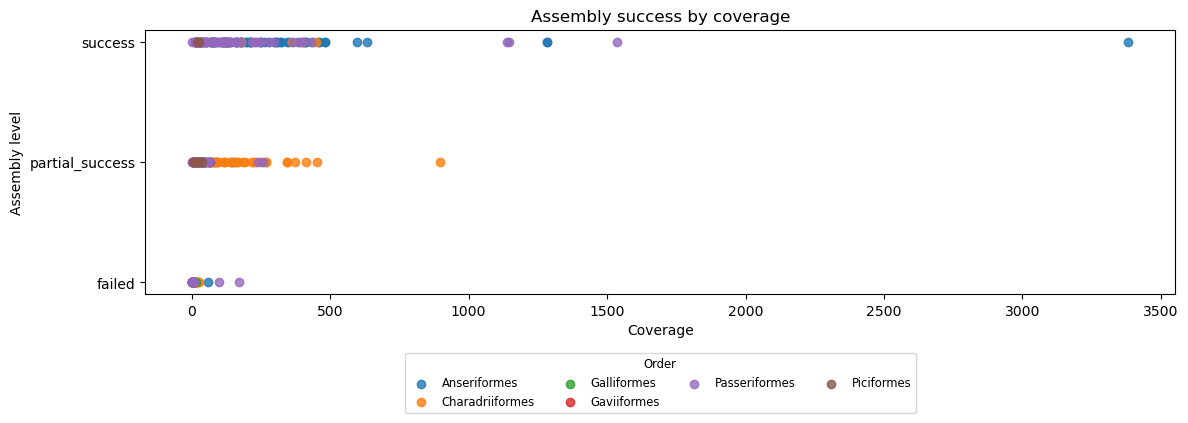

In [10]:
# Encode string assembly labels to ordinal integers using the existing level_order.
y_codes = pd.Categorical(df['assembly_level'], categories=level_order, ordered=True).codes
valid = y_codes >= 0

plot_df = df.loc[valid, ['coverage', 'order']].copy()
plot_df['y_code'] = y_codes[valid]

plt.figure(figsize=(12, 4.5))
for order_name, grp in plot_df.groupby('order'):
    plt.scatter(grp['coverage'], grp['y_code'], label=order_name, alpha=0.8)
plt.title('Assembly success by coverage')
plt.xlabel('Coverage')
plt.ylabel('Assembly level')
plt.yticks(range(len(level_order)), level_order)
plt.legend(
    title='Order',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.2),
    ncol=4,
    fontsize='small',
    title_fontsize='small'
)
plt.tight_layout()

### 3.1 Contribution of `order` and `coverage` to `assembly_level`

### Motivation

If coverage is the primary driver behind failing assemblies, there's not much I can do to increase the quality of these assemblies.
In that case, we stop here.

However, we also used a Passerine seed assembly in NOVOplasty for a group of taxonomically variable birds.
If that seed assembly increases passerine assembly success, we should reassemble the remaining taxa using taxonomically-closer references.

Since we have `assembly_level` is three ordinal labels, we can maybe model this as ordinal [logistic regression](https://www.geeksforgeeks.org/machine-learning/understanding-logistic-regression/) model with two predictors:
- `coverage` (numerical, continuous)
    - might need to be log-transformed; very-right shifted
- `order` (categorical, ordinal, multinomial)
    - imbalanced classes

### Objectives

1. Assess whether `order` or `coverage` is driving `assembly_level`
2. Predict `assembly_level` for McLaughlin birds (currently not re-assembled)

### 3.2 - Dataset preparation

We first need to one-hot encode our dataset, since we're working with a categorical value.
We're also log-transforming coverage.

In [11]:
# Keep rows with labels and predictor data
work = df.copy()
work = work[work["assembly_level"].notna() & work["coverage"].notna() & work["order"].notna()].copy()

# Define ordered target
work["assembly_level"] = pd.Categorical(work["assembly_level"], categories=level_order, ordered=True) # order defined earlier
work["y_ord"] = work["assembly_level"].cat.codes  # 0,1,2

# Coverage transforms
work["log_coverage"] = np.log10(work["coverage"] + 1e-6) # coverage skews righthand

# Design matrices for models (one-hot order; drop_first avoids full collinearity)
# Force numeric dtype to avoid statsmodels object-cast errors.
X_raw = pd.get_dummies(
    work[["coverage", "order"]],
    columns=["order"],
    drop_first=True,
    dtype=float,
).astype(float)
X_log = pd.get_dummies(
    work[["log_coverage", "order"]],
    columns=["order"],
    drop_first=True,
    dtype=float,
).astype(float)
y = work["y_ord"].astype(int).to_numpy()

We have a small number of data points (~290), so we're going to use 5-fold cross validation to figure make our results less stochastic.

### 3.2 - Testing proportional-odds assumption

It is unclear that the distance between `failure`, and `partial_success` is similar to difference between `partial_success` and `success`.

If those two things aren't roughly similar, we can't use ordinal logistic regression, and must instead use multinomial logistic regression (less powerful).

To test this, we will take each of our splits and fit them to:
- Ordinal model
    - Simpler; one covariate/slope for `assembly_level` fits all intercepts (each level)
    - +1 param
- Multinomial model
    - More complex; each `assembly_level` variant needs a separate slope
    - +3 params

The one with the better fit is the one we'll use.
Both of these are implemented in `statsmodels`.

In [12]:
# Compare ordinal vs multinomial models on identical predictors.
X = X_log.astype(float).copy()

# ---------- In-sample fit comparison ----------

# create ordered model
ord_full = OrderedModel(y, X, distr="logit").fit(method="bfgs", disp=False)

# these two create the logistic model 
X_mn_full = sm.add_constant(X, has_constant="add") # expected by a multinomial
mn_full = sm.MNLogit(y, X_mn_full).fit(method="newton", disp=False, maxiter=200)

# get log-likelihoods (raw model 'goodness')
ll_ord = float(ord_full.llf)
ll_mn = float(mn_full.llf)
# gets AIC ('goodness' controlled for complexity)
aic_ord = float(ord_full.aic)
aic_mn = float(mn_full.aic)

# LikelihoodRatio test for whether multinomial materially improves fit over ordinal.
lr_stat = 2 * (ll_mn - ll_ord) # likelihood ratio stat, as above
df_diff = int(mn_full.params.size - ord_full.params.size) # difference in param counts/degree freedom
# p-value. small means lr was improved, even with the high complexity (ie)
lr_p = float(chi2.sf(lr_stat, df_diff)) if df_diff > 0 else np.nan

fit_cmp = pd.DataFrame(
    {
        "model": ["ordinal_logit", "multinomial_logit"],
        "log_likelihood": [ll_ord, ll_mn],
        "AIC": [aic_ord, aic_mn],
    }
)
print("In-sample fit comparison")
print(fit_cmp.to_string(index=False))
print(f"\nLR test (multinomial vs ordinal): stat={lr_stat:.3f}, df={df_diff}, p={lr_p:.4g}")

In-sample fit comparison
            model  log_likelihood        AIC
    ordinal_logit     -233.270413 482.540826
multinomial_logit     -226.155643 480.311287

LR test (multinomial vs ordinal): stat=14.230, df=6, p=0.02717


/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Our AIC score suggests that the simpler, **ordinal** model performs better.
The p-value ($\gt 0.05$) also suggests that we do not reject $H_0$, where our $H_0$ is "the simpler model is fine".

However, for predictive purposes with the McLaughlin birds, we will keep the multinomial model in the cross-validation code - the models haven't seen any held-out data, and maybe rare `Orders` would change how they behave.

In [13]:
# ---------- Cross-validated predictive comparison ----------
def _safe_class_proba(p, n_classes=3):
    """Return (n, n_classes) probabilities with no NaN/Inf; rows sum to 1."""
    p = np.asarray(p, dtype=float)
    if p.ndim != 2 or p.shape[1] != n_classes:
        raise ValueError(f"Expected proba shape (n, {n_classes}), got {p.shape}")
    p = np.nan_to_num(p, nan=1.0 / n_classes, posinf=1.0, neginf=0.0)
    p = np.clip(p, 1e-12, 1.0 - 1e-12)
    row_sum = p.sum(axis=1, keepdims=True)
    p = np.divide(p, row_sum, out=np.full_like(p, 1.0 / n_classes), where=row_sum > 0)
    return p

def _append_cv_metrics(cv_rows, fold, model_name, y_true, p_hat):
    y_pred = p_hat.argmax(axis=1)
    cv_rows.append(
        {
            "fold": fold,
            "model": model_name,
            "log_loss": log_loss(y_true, p_hat, labels=[0, 1, 2]),
            "accuracy": accuracy_score(y_true, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
            "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
        }
    )

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
cv_rows = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
    # define the test dataset (will have constants added for multinomial)
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = np.asarray(y[train_idx], dtype=int)
    y_test = np.asarray(y[test_idx], dtype=int)

    # condition ordinal model
    ord_cv = OrderedModel(y_train, X_train, distr="logit").fit(method="bfgs", disp=False)
    p_ord = np.asarray(ord_cv.model.predict(ord_cv.params, exog=X_test), dtype=float)
    p_ord = _safe_class_proba(p_ord, n_classes=3)

    _append_cv_metrics(cv_rows, fold, "ordinal_logit", y_test, p_ord) # get metrics


    # Multinomial (BFGS is often more stable than Newton for ill-conditioned splits)
    X_train_mn = sm.add_constant(X_train, has_constant="add") # you need constants for multinomials
    X_test_mn = sm.add_constant(X_test, has_constant="add")

    # condition multinomial model
    mn_cv = sm.MNLogit(y_train, X_train_mn).fit(method="bfgs", disp=False, maxiter=500)
    p_mn = np.asarray(mn_cv.predict(X_test_mn), dtype=float)
    p_mn = _safe_class_proba(p_mn, n_classes=3)
    _append_cv_metrics(cv_rows, fold, "multinomial_logit", y_test, p_mn) # get metrics

cv_results = pd.DataFrame(cv_rows)
cv_summary = (
    cv_results.groupby("model")[["log_loss", "accuracy", "balanced_accuracy", "f1_weighted"]]
    .agg(["mean", "std"])
    .round(4)
)
print("\nCross-validated performance (5-fold x 3 repeats)")
print(cv_summary)


Cross-validated performance (5-fold x 3 repeats)
                  log_loss         accuracy         balanced_accuracy          \
                      mean     std     mean     std              mean     std   
model                                                                           
multinomial_logit   0.6205  0.1577   0.7698  0.0299            0.7521  0.0290   
ordinal_logit       0.5967  0.0751   0.7442  0.0441            0.7262  0.0439   

                  f1_weighted          
                         mean     std  
model                                  
multinomial_logit      0.7686  0.0299  
ordinal_logit          0.7427  0.0444  


For all 15 holdouts (5-k folds, 3 repeats), the ordinal logit performs better or similarly on our accuracy metrics.
This, alongside the results beforehand, suggests that we can treat this as an ordinal problem.

Now, because ordinality requires that the difference between `success/fail` and `fail/partial_success` be similar, we'll look at the difference between their slopes.
Similar slopes between the two suggest that the underlying patterns are similar.

In [14]:
# ---------- Quick proportional-odds plausibility check ----------
# Compare binary logit slopes for y>0 vs y>1 thresholds.
y_gt_failed = (y > 0).astype(int)        # partial/success vs failed
y_gt_partial = (y > 1).astype(int)       # success vs failed/partial
X_bin = sm.add_constant(X, has_constant="add")

bin1 = sm.Logit(y_gt_failed, X_bin).fit(disp=False)
bin2 = sm.Logit(y_gt_partial, X_bin).fit(disp=False)

po_check = pd.DataFrame(
    {
        "coef_y>failed": bin1.params,
        "coef_y>partial": bin2.params,
        "abs_diff": (bin1.params - bin2.params).abs(),
    }
).round(4)

print("\nProportional-odds plausibility (similar slopes => more plausible)")
print(po_check)


Proportional-odds plausibility (similar slopes => more plausible)
                       coef_y>failed  coef_y>partial  abs_diff
const                        -2.9698         -5.5138    2.5440
log_coverage                  4.5157          3.2012    1.3144
order_Charadriiformes        -1.2057         -2.8276    1.6219
order_Galliformes            -1.7831        -22.9303   21.1472
order_Gaviiformes            -0.7822        -25.4998   24.7176
order_Passeriformes           0.6860          0.6983    0.0123
order_Piciformes             19.2232          0.6166   18.6067


/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


For our three main taxa (Charadriiformes, Anseriformes, Passeriformes), we do, indeed, see similar coefficients.

Taxa such as Galliformes, with an absolute difference of 120+ units of difference, may be due to the small ($n=1$) number of taxa in that group.

In [15]:
# ---------- Recommendation ----------
mean_metrics = cv_results.groupby("model")[["log_loss", "accuracy", "balanced_accuracy", "f1_weighted"]].mean()
ord_metrics = mean_metrics.loc["ordinal_logit"]
mn_metrics = mean_metrics.loc["multinomial_logit"]

ord_po_diff = po_check.loc[po_check.index != "const", "abs_diff"].mean()

prefer_ordinal = False
if (ord_metrics["log_loss"] <= mn_metrics["log_loss"] + 0.01) and (ord_po_diff <= 0.5):
    prefer_ordinal = True
elif ord_metrics["log_loss"] < mn_metrics["log_loss"]:
    prefer_ordinal = True

chosen_model = "ordinal_logit" if prefer_ordinal else "multinomial_logit"

print("\nModel recommendation")
print(f"Chosen model: {chosen_model}")
print(
    f"Reasoning: CV log-loss ordinal={ord_metrics['log_loss']:.4f}, "
    f"multinomial={mn_metrics['log_loss']:.4f}; "
    f"mean threshold-slope abs diff={ord_po_diff:.4f}."
)


Model recommendation
Chosen model: ordinal_logit
Reasoning: CV log-loss ordinal=0.5967, multinomial=0.6205; mean threshold-slope abs diff=11.2367.


This settles it: we'll use an ordinal model.

### 3.4 Coefficients of ordinal model

Now that we have our model, the question is whether or not `order` is more significant in predicting `assembly_value` than `coverage`.
Since we have a drastic range of coverage values (over 4x difference in magnitude), we'll run both a raw and log-transformed model:

In [16]:
# ---------- Ordinal model diagnostics and effect sizes ----------
# Refit final ordinal models on full data using raw and log coverage.
ord_full_log = OrderedModel(y, X_log.astype(float), distr="logit").fit(method="bfgs", disp=False)
ord_full_raw = OrderedModel(y, X_raw.astype(float), distr="logit").fit(method="bfgs", disp=False)

# define helpers
def _coef_table(fitted, label):
    coef = fitted.params.copy()
    coef = coef[~coef.index.str.contains("/")]  # remove threshold cutpoints
    out = pd.DataFrame(
        {
            "model": label,
            "term": coef.index,
            "coef": coef.values,
            "abs_coef": np.abs(coef.values),
            "odds_ratio": np.exp(coef.values),
        }
    )
    return out

def _mcfadden_r2(ll_model, ll_null):
    if np.isfinite(ll_null) and ll_null != 0:
        return 1.0 - (ll_model / ll_null)
    return np.nan

In [17]:
# Pseudo-R^2 values (McFadden) using model-provided null log-likelihood when available.
ll_null = getattr(ord_full_log, "llnull", np.nan)

r2_tbl = pd.DataFrame(
    {
        "model": ["ordinal_raw_coverage", "ordinal_log_coverage"],
        "log_likelihood": [ord_full_raw.llf, ord_full_log.llf],
        "AIC": [ord_full_raw.aic, ord_full_log.aic],
        "McFadden_R2": [
            _mcfadden_r2(ord_full_raw.llf, ll_null),
            _mcfadden_r2(ord_full_log.llf, ll_null),
        ],
    }
).round(4)

# Correlations:
# 1) association with outcome (assembly level, encoded ordinally)
# 2) association between predictors (coverage vs taxonomic order)
work_corr = work.copy()
work_corr["order_code"] = pd.Categorical(work_corr["order"]).codes

corr_tbl = pd.DataFrame(
    {
        "metric": [
            "Spearman(coverage, assembly_level)",
            "Spearman(log_coverage, assembly_level)",
            "Spearman(coverage, order_code)",
            "Spearman(log_coverage, order_code)",
        ],
        "value": [
            work_corr["coverage"].corr(work_corr["y_ord"], method="spearman"),
            work_corr["log_coverage"].corr(work_corr["y_ord"], method="spearman"),
            work_corr["coverage"].corr(work_corr["order_code"], method="spearman"),
            work_corr["log_coverage"].corr(work_corr["order_code"], method="spearman"),
        ],
    }
).round(4)

coef_tbl = pd.concat(
    [
        _coef_table(ord_full_raw, "ordinal_raw_coverage"),
        _coef_table(ord_full_log, "ordinal_log_coverage"),
    ],
    ignore_index=True,
)

In [18]:
print("\nFinal model object to use for prediction:")
print("- ord_full_log (ordinal model with log_coverage + order dummies)")

print("\nPseudo-R^2 / fit summary")
print(r2_tbl.to_string(index=False))

print("\nCorrelation summary")
print(corr_tbl.to_string(index=False))

print("\nCoefficient summary (larger |coef| => stronger effect on log-odds scale)")
print(coef_tbl.sort_values(["model", "abs_coef"], ascending=[True, False]).round(4).to_string(index=False))


Final model object to use for prediction:
- ord_full_log (ordinal model with log_coverage + order dummies)

Pseudo-R^2 / fit summary
               model  log_likelihood      AIC  McFadden_R2
ordinal_raw_coverage       -314.0978 644.1957       0.2522
ordinal_log_coverage       -233.2704 482.5408       0.4446

Correlation summary
                                metric   value
    Spearman(coverage, assembly_level)  0.7147
Spearman(log_coverage, assembly_level)  0.7147
        Spearman(coverage, order_code) -0.1825
    Spearman(log_coverage, order_code) -0.1825

Coefficient summary (larger |coef| => stronger effect on log-odds scale)
               model                  term    coef  abs_coef  odds_ratio
ordinal_log_coverage          log_coverage  3.5997    3.5997     36.5865
ordinal_log_coverage     order_Galliformes -2.0266    2.0266      0.1318
ordinal_log_coverage order_Charadriiformes -2.0186    2.0186      0.1328
ordinal_log_coverage     order_Gaviiformes -1.5772    1.5772      0

We can tell that log-transformation fits a lot better than not-log-transforming by AIC.
`log_coverage` is obviously the strongest predictor, which makes sense because... you know, it's a whole order of magnitude for a 1-point increase.

More broadly, though, we can see a much stronger correlation (Spearman) between coverage ($corr_{cov}=0.6625$) and assembly level than order and assembly level ($corr_{ord}=-0.216$).
Except, since order is one-hot-encoded, the actual effect size isn't very good.

In [19]:
# ---------- Coefficient significance + overall order LR test ----------
# Use existing objects if present; otherwise fit here.
if "ord_full_log" not in globals():
    ord_full_log = OrderedModel(y, X_log.astype(float), distr="logit").fit(method="bfgs", disp=False)

# Reduced model: log_coverage only (no order dummies)
X_log_only = X_log[["log_coverage"]].astype(float)
ord_log_only = OrderedModel(y, X_log_only, distr="logit").fit(method="bfgs", disp=False)

# Build coefficient inference table (exclude threshold cutpoints like "0/1", "1/2")
params = ord_full_log.params
bse = ord_full_log.bse
pvals = ord_full_log.pvalues
ci = ord_full_log.conf_int()

coef_idx = [idx for idx in params.index if "/" not in idx]
coef_infer = pd.DataFrame(
    {
        "term": coef_idx,
        "coef": params.loc[coef_idx].values,
        "SE": bse.loc[coef_idx].values,
        "z": (params.loc[coef_idx] / bse.loc[coef_idx]).values,
        "p_value": pvals.loc[coef_idx].values,
        "OR": np.exp(params.loc[coef_idx].values),
        "OR_CI_low": np.exp(ci.loc[coef_idx, 0].values),
        "OR_CI_high": np.exp(ci.loc[coef_idx, 1].values),
    }
).round(4)

# Likelihood-ratio test: does order improve fit beyond log_coverage alone?
ll_full = float(ord_full_log.llf)
ll_reduced = float(ord_log_only.llf)
lr_stat = 2.0 * (ll_full - ll_reduced)

df_diff = int(ord_full_log.params.size - ord_log_only.params.size)
lr_p = float(chi2.sf(lr_stat, df_diff)) if df_diff > 0 else np.nan

print("\nCoefficient inference table (ordinal logit; predictors only)")
print(coef_infer.sort_values("p_value").to_string(index=False))

print("\nOverall order effect (LR test): full = log_coverage + order, reduced = log_coverage only")
print(f"LR stat={lr_stat:.4f}, df={df_diff}, p={lr_p:.4g}")



Coefficient inference table (ordinal logit; predictors only)
                 term    coef     SE       z  p_value      OR  OR_CI_low  OR_CI_high
         log_coverage  3.5997 0.2853 12.6193   0.0000 36.5865    20.9177     63.9922
order_Charadriiformes -2.0186 0.3199 -6.3096   0.0000  0.1328     0.0710      0.2487
    order_Galliformes -2.0266 0.7872 -2.5743   0.0100  0.1318     0.0282      0.6165
  order_Passeriformes  0.6873 0.3083  2.2297   0.0258  1.9884     1.0867      3.6382
    order_Gaviiformes -1.5772 0.8057 -1.9575   0.0503  0.2066     0.0426      1.0020
     order_Piciformes  1.1486 0.8468  1.3564   0.1750  3.1537     0.5998     16.5813

Overall order effect (LR test): full = log_coverage + order, reduced = log_coverage only
LR stat=87.9670, df=5, p=1.796e-17


In [20]:
# ---------- Kruskal-Wallis: assembly level differences across orders ----------
# Nonparametric omnibus test for whether assembly_level distributions differ by taxonomic order.
kw_df = work[["order", "y_ord"]].dropna().copy()
order_groups = [grp["y_ord"].to_numpy() for _, grp in kw_df.groupby("order")]

valid_groups = [g for g in order_groups if len(g) > 0]
if len(valid_groups) < 2:
    raise ValueError("Need at least two non-empty order groups for Kruskal-Wallis test.")

h_stat, p_val = kruskal(*valid_groups)

group_sizes = (
    kw_df.groupby("order").size().sort_values(ascending=False).rename("n").to_frame()
)

print("\nKruskal-Wallis test: y_ord ~ order")
print(f"H={h_stat:.4f}, df={len(valid_groups)-1}, p={p_val:.4g}")
print("\nGroup sizes by order")
print(group_sizes.to_string())


Kruskal-Wallis test: y_ord ~ order
H=63.0469, df=5, p=2.847e-12

Group sizes by order
                   n
order               
Anseriformes     138
Passeriformes    126
Charadriiformes  115
Galliformes        9
Gaviiformes        9
Piciformes         7


Order is significant, but we don't know which ones are significant.

It could be driven only by the small number of Galliformes, Gaviiformes and Piciformes in the dataset.

Because Kruskal-Wallis is pretty similar to ANOVA, we're going to use the Dunn post-hoc test to assess what ones differ.

In [21]:
# ---------- Dunn post-hoc test (pairwise order comparisons) ----------
# Run this after the Kruskal-Wallis cell.
try:
    import scikit_posthocs as sp
except ImportError as exc:
    raise ImportError(
        "Dunn test requires scikit-posthocs. Install with: pip install scikit-posthocs"
    ) from exc

# Use same data source as Kruskal-Wallis: ordinal assembly level by order.
dunn_df = work[["order", "y_ord"]].dropna().copy()

# Pairwise Dunn test with multiple-testing correction.
# p_adjust options include: 'bonferroni', 'holm', 'fdr_bh', etc.
dunn_p = sp.posthoc_dunn(
    dunn_df,
    val_col="y_ord",
    group_col="order",
    p_adjust="holm",
)

print("\nDunn post-hoc test (Holm-adjusted p-values)")
print(dunn_p.round(4).to_string())

# Optional tidy long-format table for easier filtering/reporting.
dunn_long = (
    dunn_p.where(np.triu(np.ones(dunn_p.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
dunn_long.columns = ["order_1", "order_2", "p_adj_holm"]
dunn_long = dunn_long.sort_values("p_adj_holm")

print("\nTop pairwise differences (smallest adjusted p-values)")
print(dunn_long.head(20).round(6).to_string(index=False))


Dunn post-hoc test (Holm-adjusted p-values)
                 Anseriformes  Charadriiformes  Galliformes  Gaviiformes  Passeriformes  Piciformes
Anseriformes           1.0000           0.0000       0.0413       0.0413         1.0000      1.0000
Charadriiformes        0.0000           1.0000       1.0000       1.0000         0.0000      0.6607
Galliformes            0.0413           1.0000       1.0000       1.0000         0.0932      0.7480
Gaviiformes            0.0413           1.0000       1.0000       1.0000         0.0932      0.7480
Passeriformes          1.0000           0.0000       0.0932       0.0932         1.0000      1.0000
Piciformes             1.0000           0.6607       0.7480       0.7480         1.0000      1.0000

Top pairwise differences (smallest adjusted p-values)
        order_1         order_2  p_adj_holm
   Anseriformes Charadriiformes    0.000000
Charadriiformes   Passeriformes    0.000000
   Anseriformes     Galliformes    0.041347
   Anseriformes     Gavi

We find significant differences between Anseriformes and Charadriiformes, as well as Charadriiformes and Passeriformes.

The thing we wanted to test -whether or not the use of a Passeriform refseq biases us towards Passeriformes- doesn't seem to be occurring.
We do not see evidence of bias, and -consistent with NOVOplasty's stated documentation- we are not experiencing bias towards passerine birds.